# Notebook 06 — FastDreemTCN : CNN Réduction + TCN rapide
## Challenge ENS #45 — Dreem Sleep Apnea Detection

| Section | Contenu |
|---|---|
| 1 | Diagnostic overfitting & pipeline FastTCN |
| 2 | Setup & configuration |
| 3 | Chargement données + subject IDs |
| 4 | Architecture FastDreemTCN |
| 5 | Dataset avec instance normalization |
| 6 | Métriques F1-IoU officielles |
| 7 | GroupKFold 5 folds |
| 8 | Calibration threshold OOF |
| 9 | Entraînement final + submission_v6.csv |
| 10 | Conclusion & comparaison |

---

## 1. Diagnostic de l'overfitting & architecture FastTCN

### Pourquoi CNN+BiLSTM obtient 0.80 val → 0.36 public

Deux causes cumulées expliquent intégralement le gap de généralisation :

**Cause 1 — Normalisation globale inadaptée au test**

Le `StandardScaler` du notebook 02 est fitté sur les 17 sujets train.
Les sujets test (IDs 22–43) ont des distributions physiologiques inconnues :
SpO₂ basale de 74 % à 99 %, AirFlow d'amplitude ×5. Appliquer `(x - μ_train) / σ_train`
à ces sujets produit des features hors distribution — le modèle reçoit des valeurs jamais vues.

→ **Fix : Instance Normalization** — chaque fenêtre normalisée par ses propres `μ` et `σ`.

**Cause 2 — Validation biaisée (5 sujets légers, toujours les mêmes)**

Les 5 sujets de validation `{0,1,8,13,15}` ont un taux d'apnée moyen de 4.5 %,
bien inférieur à la moyenne train (7.56 %). Val F1 = 0.80 est une surestimation systématique.

→ **Fix : GroupKFold 5 folds** — chaque sujet passe exactement 1 fois en validation.

---

### Architecture FastDreemTCN : pourquoi c'est rapide

Le TCN naïf sur 9000 points est lent (chaque convolution traite 9000 valeurs).
L'idée : **réduire d'abord × 100 avec des Conv stride, puis appliquer le TCN
sur 90 points** (1 point par seconde cible). Le TCN ne voit que 90 timesteps.

```
Pipeline complet
════════════════════════════════════════════════════════════════════
Input         (batch,   8, 9000)
──────────────────────────────────────────────── CNN Réduction ×100
ConvBlock 1   (batch,  32, 1800)  stride=5,  k=11
ConvBlock 2   (batch,  64,  360)  stride=5,  k=9
ConvBlock 3   (batch, 128,   90)  stride=4,  k=5
──────────────────────────────────────────────── TCN sur 90 pts
TCNBlock d=1  (batch, 128,   90)  RF = 5 pts  =  5s
TCNBlock d=2  (batch, 128,   90)  RF = 9 pts  =  9s
TCNBlock d=4  (batch, 128,   90)  RF = 17 pts = 17s ← durée médiane apnée
TCNBlock d=8  (batch, 128,   90)  RF = 33 pts = 33s
──────────────────────────────────────────────── Tête segmentation
Conv1d(128→1) (batch,   1,   90)  pixel-wise
Squeeze       (batch,      90)  logits bruts
════════════════════════════════════════════════════════════════════

Champ récepteur TCN = 1 + 2×(3-1)×(1+2+4+8) = 61 pts @ 1 pt/s = 61 s
→ couvre toute la fenêtre de 90 s en contexte effectif
```

> *Référence : Bai et al. (2018). "An empirical evaluation of generic convolutional
> and recurrent networks for sequence modeling." arXiv:1803.01271*

In [19]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, sys, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupKFold
from scipy.ndimage import median_filter

warnings.filterwarnings('ignore')
print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")

PyTorch : 2.10.0+cu128
NumPy   : 2.0.2


In [20]:
# ── Auto-détection Kaggle ─────────────────────────────────────────────────────
IS_KAGGLE = os.path.exists('/kaggle/working')

if IS_KAGGLE:
    DATA_DIR    = Path('/kaggle/input/datasets/tholinale/dreem-processed/')
    RAW_DIR     = Path('/kaggle/input/datasets/tholinale/dreem-processed/')
    OUTPUT_DIR  = Path('/kaggle/working/')
    FIGURES_DIR = Path('/kaggle/working/figures/')
    SUBMIT_DIR  = Path('/kaggle/working/')
else:
    DATA_DIR    = Path('../data/processed/')
    RAW_DIR     = Path('../data/raw/')
    OUTPUT_DIR  = Path('../data/submissions/')
    FIGURES_DIR = Path('../figures/')
    SUBMIT_DIR  = Path('../data/submissions/')

for d in [OUTPUT_DIR, FIGURES_DIR, SUBMIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Constantes ────────────────────────────────────────────────────────────────
RANDOM_SEED       = 42
N_SIGNALS         = 8
N_SAMPLES         = 9000
N_LABEL_COLS      = 90
SIGNAL_FREQ       = 100
N_WINDOWS_PER_SUB = 200
POS_WEIGHT        = 12.23
VAL_SUBJECTS_ORIG = [0, 1, 8, 13, 15]

SIGNAL_NAMES = ['AbdoBelt','AirFlow','PPG','ThorBelt',
                'Snoring','SpO2','EEG C4-A1','EEG O2-A1']

# ── Seed & device ─────────────────────────────────────────────────────────────
def set_seed(s=RANDOM_SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()

if   torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available():    device = torch.device('mps')
else:                                      device = torch.device('cpu')

print(f"IS_KAGGLE : {IS_KAGGLE}")
print(f"Device    : {device}" + (f" — {torch.cuda.get_device_name(0)}"
                                   if device.type=='cuda' else ""))
print(f"DATA_DIR  : {DATA_DIR.resolve()}")

IS_KAGGLE : True
Device    : cuda — Tesla T4
DATA_DIR  : /kaggle/input/datasets/tholinale/dreem-processed


---

## 3. Chargement des données & subject IDs

### Source des subject IDs

Le fichier `X_train_h7ipJUo.csv` (colonnes `ID`, `Subject_ID`) mappe chaque fenêtre
à son sujet d'origine sur les **4400 fenêtres labellisées** (22 sujets × 200 fenêtres).

`X_train_processed.npy` contient les 3400 fenêtres des **17 sujets train** (sujets
`{0,1,8,13,15}` exclus). En chargeant le CSV et en filtrant sur les mêmes sujets,
on obtient le `subject_id` de chaque sample pour `GroupKFold`.

**Fallback automatique** : si le CSV est absent (datasets Kaggle sans raw files),
les subject IDs sont reconstruits depuis `VAL_SUBJECTS_ORIG` et `N_WINDOWS_PER_SUB`.

In [21]:
# ── Chargement memory-mapped ──────────────────────────────────────────────────
X_train = np.load(DATA_DIR / 'X_train_processed.npy', mmap_mode='r')  # (3400,8,9000)
y_train = np.load(DATA_DIR / 'y_train_processed.npy')                  # (3400,90)
X_test  = np.load(DATA_DIR / 'X_test_processed.npy',  mmap_mode='r')  # (4400,8,9000)

print("Fichiers chargés :")
print(f"  X_train : {X_train.shape}  mmap")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}  mmap")

# ── Subject IDs pour GroupKFold ───────────────────────────────────────────────
csv_candidates = [
    RAW_DIR  / 'X_train_h7ipJUo.csv',
    DATA_DIR / 'X_train_h7ipJUo.csv',
]
csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is not None:
    df_meta  = pd.read_csv(csv_path)                          # colonnes: ID, Subject_ID
    # Garder uniquement les sujets train (exclusion VAL_SUBJECTS_ORIG)
    df_train = df_meta[~df_meta['Subject_ID'].isin(VAL_SUBJECTS_ORIG)].reset_index(drop=True)
    subject_ids = df_train['Subject_ID'].values.astype(int)   # (3400,)
    print(f"\nSubject IDs chargés depuis : {csv_path.name}")
else:
    # Fallback : reconstruction séquentielle (200 fenêtres / sujet, sujets train)
    all_subs   = np.repeat(np.arange(22), N_WINDOWS_PER_SUB)          # (4400,)
    train_mask = ~np.isin(all_subs, VAL_SUBJECTS_ORIG)
    subject_ids = all_subs[train_mask]                                  # (3400,)
    print("\n⚠ CSV absent — subject IDs reconstruits par dérivation séquentielle")

assert len(subject_ids) == len(X_train),     f"Mismatch subject_ids({len(subject_ids)}) vs X_train({len(X_train)})"

unique_subs, counts = np.unique(subject_ids, return_counts=True)
print(f"Sujets uniques  : {sorted(unique_subs.tolist())}")
print(f"Fenêtres/sujet  : {dict(zip(unique_subs.tolist(), counts.tolist()))}")
print(f"% apnées train  : {y_train.mean()*100:.2f}%")

# ── test_ids confirmés sur y_benchmark.csv ────────────────────────────────────
test_ids = np.arange(4400, 8800)
print(f"test_ids        : {test_ids.shape}  [{test_ids[0]}…{test_ids[-1]}]")

Fichiers chargés :
  X_train : (3400, 8, 9000)  mmap
  y_train : (3400, 90)
  X_test  : (4400, 8, 9000)  mmap

⚠ CSV absent — subject IDs reconstruits par dérivation séquentielle
Sujets uniques  : [2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21]
Fenêtres/sujet  : {2: 200, 3: 200, 4: 200, 5: 200, 6: 200, 7: 200, 9: 200, 10: 200, 11: 200, 12: 200, 14: 200, 16: 200, 17: 200, 18: 200, 19: 200, 20: 200, 21: 200}
% apnées train  : 7.56%
test_ids        : (4400,)  [4400…8799]


---

## 4. Architecture FastDreemTCN

### ConvReductionBlock — réduction de séquence par stride

Chaque bloc CNN réduit la longueur temporelle par `stride` tout en augmentant
le nombre de canaux. Trois blocs enchaînés réduisent 9000 → 1800 → 360 → 90.

### TCNResidualBlock — contexte temporel sur séquence courte

Bloc résiduel avec **deux convolutions dilatées** + skip connection.
À 1 point par seconde (après réduction), la dilatation `d` couvre `d` secondes.
Avec les 4 blocs `d ∈ {1,2,4,8}`, le champ récepteur effectif couvre **61 secondes**
— soit toute la fenêtre de 90 s, en ne traitant que 90 points au lieu de 9000.

In [22]:
class ConvReductionBlock(nn.Module):
    """
    Bloc CNN 1D avec stride pour réduire la séquence temporelle.
    Conv1d → BatchNorm1d → ReLU

    Paramètres
    ----------
    in_ch  : canaux entrée
    out_ch : canaux sortie
    k      : taille du noyau
    stride : facteur de réduction
    pad    : padding symétrique
    """
    def __init__(self, in_ch, out_ch, k, stride, pad):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, stride=stride, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class TCNResidualBlock(nn.Module):
    """
    Bloc TCN résiduel avec convolution dilatée sur séquence courte (90 pts).

    Flux :
        x → Conv(d)→BN→ReLU → Conv(d)→BN → Dropout → + skip(x) → ReLU

    padding = dilation → conserve la longueur de séquence.
    Skip connection : identité (même nombre de canaux dans tous les blocs TCN).

    Paramètres
    ----------
    channels : int  — canaux (identiques entrée/sortie)
    dilation : int  — facteur de dilatation (1, 2, 4, 8)
    dropout  : float — taux de dropout (défaut 0.2)
    """
    def __init__(self, channels: int, dilation: int, dropout: float = 0.2):
        super().__init__()
        pad = dilation
        self.conv1 = nn.Conv1d(channels, channels, 3, dilation=dilation,
                               padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, dilation=dilation,
                               padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(channels)
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        h = self.relu(self.bn1(self.conv1(x)))
        h = self.drop(self.bn2(self.conv2(h)))
        return self.relu(h + x)   # skip connection identité


class FastDreemTCN(nn.Module):
    """
    CNN réduction ×100 + TCN sur 90 pts + tête de segmentation.

    Flux :
        (batch, 8, 9000)
        ──── CNN Réduction ×100 ────
        → ConvBlock(8→32,  stride=5) : (batch,  32, 1800)
        → ConvBlock(32→64, stride=5) : (batch,  64,  360)
        → ConvBlock(64→128,stride=4) : (batch, 128,   90)
        ──── TCN 4 blocs ────
        → TCN d=1 : (batch, 128, 90)   RF = 5 pts  =  5 s
        → TCN d=2 : (batch, 128, 90)   RF = 9 pts  =  9 s
        → TCN d=4 : (batch, 128, 90)   RF = 17 pts = 17 s ← médiane apnée
        → TCN d=8 : (batch, 128, 90)   RF = 33 pts = 33 s
        ──── Segmentation ────
        → Conv1d(128→1, k=1) : (batch, 1, 90)
        → squeeze             : (batch, 90)   logits

    Champ récepteur TCN (4 blocs, k=3) :
        RF = 1 + 2*(3-1)*(1+2+4+8) = 61 pts = 61 s @ 1 pt/s
    """
    def __init__(self, n_channels: int = 8, dropout: float = 0.2):
        super().__init__()

        # ── Encodeur CNN — réduction ×100 exacte ─────────────────────────────
        # 9000 → 1800 → 360 → 90
        self.encoder = nn.Sequential(
            ConvReductionBlock(n_channels, 32,  k=11, stride=5, pad=5),
            ConvReductionBlock(32,         64,  k=9,  stride=5, pad=4),
            ConvReductionBlock(64,         128, k=5,  stride=4, pad=2),
        )

        # ── TCN sur 90 pts — 4 blocs dilatés ─────────────────────────────────
        self.tcn = nn.Sequential(
            TCNResidualBlock(128, dilation=1, dropout=dropout),
            TCNResidualBlock(128, dilation=2, dropout=dropout),
            TCNResidualBlock(128, dilation=4, dropout=dropout),
            TCNResidualBlock(128, dilation=8, dropout=dropout),
        )

        # ── Tête de segmentation pixel-wise ──────────────────────────────────
        self.head = nn.Conv1d(128, 1, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.encoder(x)   # (batch, 128, 90)
        x = self.tcn(x)       # (batch, 128, 90)
        x = self.head(x)      # (batch,   1, 90)
        return x.squeeze(1)   # (batch,      90)


# ── Vérifications ─────────────────────────────────────────────────────────────
_m   = FastDreemTCN()
_x   = torch.zeros(2, N_SIGNALS, N_SAMPLES)
_out = _m(_x)
assert _out.shape == (2, N_LABEL_COLS), f"Shape inattendue : {_out.shape}"

n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
rf_tcn   = 1 + 2*(3-1)*(1+2+4+8)   # champ récepteur analytique en pts (= secondes)

print("FastDreemTCN défini.")
print(f"  Paramètres entraînables : {n_params:,}")
print(f"  Champ récepteur TCN     : {rf_tcn} pts = {rf_tcn} s @ 1 pt/s (après CNN réduction)")
print(f"  Forward pass            : {_x.shape} → {_out.shape}  ✓")
del _m, _x, _out

FastDreemTCN défini.
  Paramètres entraînables : 458,049
  Champ récepteur TCN     : 61 pts = 61 s @ 1 pt/s (après CNN réduction)
  Forward pass            : torch.Size([2, 8, 9000]) → torch.Size([2, 90])  ✓


---

## 5. Dataset avec instance normalization

L'**instance normalization** est appliquée dans `__getitem__` à chaque fenêtre :

```
μ[c] = mean(x[c])  ∀ canal c  →  (8,1)
σ[c] = std(x[c])   ∀ canal c  →  (8,1)
x̂[c] = (x[c] − μ[c]) / (σ[c] + 1e-8)
```

Chaque fenêtre est normalisée par rapport à **elle-même**, sans référence
aux statistiques des autres sujets. Robuste aux sujets test inconnus.

In [23]:
class DreemDatasetFast(Dataset):
    """
    Dataset PyTorch avec instance normalization par fenêtre.

    Paramètres
    ----------
    X       : np.ndarray ou np.memmap (N, 8, 9000)
    y       : np.ndarray ou None (N, 90)
    augment : bool — active les augmentations (train uniquement)
    """
    def __init__(self, X, y=None, augment=False):
        self.X       = X
        self.y       = y
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].copy().astype(np.float32)       # (8, 9000)

        # ── Instance normalization ─────────────────────────────────────────────
        x = (x - x.mean(axis=-1, keepdims=True)) /             (x.std(axis=-1,  keepdims=True) + 1e-8)

        # ── Augmentations (train uniquement) ──────────────────────────────────
        if self.augment:
            if np.random.random() < 0.5:                # bruit gaussien σ=0.02
                x += np.random.normal(0, 0.02, x.shape).astype(np.float32)
            if np.random.random() < 0.5:                # time shift ±100 pts
                x = np.roll(x, int(np.random.randint(-100, 101)), axis=-1)

        xt = torch.tensor(x, dtype=torch.float32)
        if self.y is not None:
            return xt, torch.tensor(self.y[idx].copy(), dtype=torch.float32)
        return xt


# ── Vérification ──────────────────────────────────────────────────────────────
_ds = DreemDatasetFast(X_train, y_train, augment=True)
_x, _y = _ds[0]
print(f"Dataset OK — x: {_x.shape}  y: {_y.shape}")
print(f"  mean={_x.mean():.4f}  std={_x.std():.4f}  (≈0 / ≈1 grâce à instance norm)")
del _ds, _x, _y

Dataset OK — x: torch.Size([8, 9000])  y: torch.Size([90])
  mean=0.0000  std=1.0001  (≈0 / ≈1 grâce à instance norm)


---

## 6. Métriques officielles F1-IoU

Implémentation exacte du scoring ENS #45 : F1 basé sur l'IoU entre événements
(seuil IoU = 0.3). Un événement prédit est un TP si son chevauchement avec
un événement de référence ≥ 0.3.

In [24]:
def extract_events(mask):
    """Masque binaire (T,) → liste de (start, end)."""
    m = np.concatenate([[0], mask.astype(int), [0]])
    d = np.diff(m)
    return list(zip(np.where(d == 1)[0], np.where(d == -1)[0]))

def _iou(a0,a1,b0,b1):
    inter = max(0, min(a1,b1)-max(a0,b0))
    union = (a1-a0)+(b1-b0)-inter
    return inter/union if union else 0.

def compute_f1_iou(y_true, y_pred, iou_threshold=0.3):
    """F1-IoU officiel ENS #45 (seuil IoU=0.3)."""
    te, pe = extract_events(y_true), extract_events(y_pred)
    if not te and not pe: return 1.
    if not te or  not pe: return 0.
    matched, tp = set(), 0
    for ps,pe_ in pe:
        best, bj = 0., -1
        for j,(ts,te_) in enumerate(te):
            if j in matched: continue
            v = _iou(ps,pe_,ts,te_)
            if v > best: best,bj = v,j
        if best >= iou_threshold: tp+=1; matched.add(bj)
    fp,fn = len(pe)-tp, len(te)-tp
    d = 2*tp+fp+fn
    return 2*tp/d if d else 0.

def compute_batch_f1(y_true, y_probs, threshold=0.5):
    """F1-IoU moyen sur un batch (probs → binarisation → F1 par sample)."""
    yb = (y_probs >= threshold).astype(int)
    return float(np.mean([compute_f1_iou(y_true[i], yb[i]) for i in range(len(y_true))]))

def apply_median_filter(probs, kernel_size=5):
    """Filtre médian le long de l'axe temporel, indépendant par sample."""
    return median_filter(probs, size=(1, kernel_size)).astype(np.float32)

def calibrate_threshold(y_true, y_probs, kernel_size=5, lo=0.10, hi=0.91, step=0.05):
    """
    Threshold optimal sur y_probs après filtre médian.
    Retourne (best_thr, best_f1, f1_array, thresholds).
    """
    ps  = apply_median_filter(y_probs, kernel_size)
    thr = np.arange(lo, hi, step)
    f1s = np.array([compute_batch_f1(y_true, ps, t) for t in thr])
    i   = int(np.argmax(f1s))
    return float(thr[i]), float(f1s[i]), f1s, thr

print("Métriques définies : extract_events, compute_f1_iou, compute_batch_f1,")
print("                     apply_median_filter, calibrate_threshold")

Métriques définies : extract_events, compute_f1_iou, compute_batch_f1,
                     apply_median_filter, calibrate_threshold


---

## 7. GroupKFold 5 folds

### Estimation honnête vs split biaisé

`GroupKFold(n_splits=5)` interdit à tout sujet d'être simultanément en train
et en val d'un même fold. Avec 17 sujets :

```
Fold 1 : train ≈ 13–14 sujets | val = 3–4 sujets (600–800 fenêtres)
Fold 2 : train ≈ 13–14 sujets | val = 3–4 sujets (autres)
…
Fold 5 : train ≈ 13–14 sujets | val = 3–4 sujets (les derniers)
```

Après 5 folds, **chaque fenêtre a une prédiction OOF** faite par un modèle
n'ayant jamais vu le sujet correspondant. Le F1 OOF est l'estimateur non biaisé
du score public ENS.

In [25]:
# ── Hyperparamètres ───────────────────────────────────────────────────────────
N_FOLDS    = 5
MAX_EPOCHS = 40
PATIENCE   = 8
BS_TRAIN   = 32
BS_VAL     = 64
LR         = 1e-3
WD         = 1e-4
KERN_MED   = 5

# ── Stockage OOF ──────────────────────────────────────────────────────────────
oof_probs   = np.zeros((len(X_train), N_LABEL_COLS), dtype=np.float32)
fold_results= []
best_fold_f1  = -np.inf
best_fold_num = -1
best_fold_path= OUTPUT_DIR / 'best_fold_model.pth'

gkf = GroupKFold(n_splits=N_FOLDS)

print(f"GroupKFold {N_FOLDS} folds | {MAX_EPOCHS} epochs max | patience={PATIENCE}")
print("=" * 65)

for fold, (tr_idx, va_idx) in enumerate(
        gkf.split(X_train, y_train, groups=subject_ids), start=1):

    val_subs = sorted(set(subject_ids[va_idx].tolist()))
    print(f"\nFold {fold}/{N_FOLDS} | Sujets val: {val_subs} "
          f"| Train: {len(tr_idx)} | Val: {len(va_idx)}")

    # ── DataLoaders ────────────────────────────────────────────────────────────
    nw = 2 if device.type != 'mps' else 0
    dl_tr = DataLoader(
        DreemDatasetFast(X_train[tr_idx], y_train[tr_idx], augment=True),
        batch_size=BS_TRAIN, shuffle=True, num_workers=nw,
        pin_memory=(device.type=='cuda'))
    dl_va = DataLoader(
        DreemDatasetFast(X_train[va_idx], y_train[va_idx], augment=False),
        batch_size=BS_VAL, shuffle=False, num_workers=nw,
        pin_memory=(device.type=='cuda'))

    # ── Modèle ────────────────────────────────────────────────────────────────
    model   = FastDreemTCN(n_channels=N_SIGNALS).to(device)
    crit    = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([POS_WEIGHT]).to(device))
    optim   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
        optim, T_max=MAX_EPOCHS, eta_min=1e-5)

    best_f1_fold, best_ep, pat_cnt, best_state = -np.inf, 0, 0, None

    # ── Boucle epochs ─────────────────────────────────────────────────────────
    for epoch in range(1, MAX_EPOCHS + 1):

        # Train
        model.train(); tr_loss = 0.
        for xb, yb in dl_tr:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optim.zero_grad(set_to_none=True)
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            tr_loss += loss.item()
        tr_loss /= len(dl_tr)
        sched.step()

        # Val — collecte probs
        model.eval(); vp, vl = [], []
        with torch.no_grad():
            for xb, yb in dl_va:
                p = torch.sigmoid(model(xb.to(device))).cpu().numpy()
                vp.append(p); vl.append(yb.numpy())
        vp = np.concatenate(vp); vl = np.concatenate(vl)

        # F1 avec filtre médian (threshold fixe 0.5 pendant training)
        f1 = compute_batch_f1(vl, apply_median_filter(vp, KERN_MED), threshold=0.5)

        mark = ''
        if f1 > best_f1_fold:
            best_f1_fold = f1; best_ep = epoch; pat_cnt = 0
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            mark = ' ← ✓'
        else:
            pat_cnt += 1

        if epoch % 5 == 0 or mark:
            print(f"  Epoch {epoch:02d}/{MAX_EPOCHS} | "
                  f"Loss: {tr_loss:.4f} | Val F1: {f1:.4f}{mark}")

        if pat_cnt >= PATIENCE:
            print(f"  Early stopping à l'epoch {epoch}"); break

    print(f"  → Fold {fold} | Best Val F1: {best_f1_fold:.4f} (epoch {best_ep})")

    # ── OOF avec meilleur modèle ───────────────────────────────────────────────
    model.load_state_dict(best_state); model.eval()
    dl_oof = DataLoader(DreemDatasetFast(X_train[va_idx], augment=False),
                        batch_size=BS_VAL, shuffle=False, num_workers=nw)
    parts = []
    with torch.no_grad():
        for xb in dl_oof:
            parts.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    oof_probs[va_idx] = np.concatenate(parts)

    # ── Sauvegarde meilleur fold global ───────────────────────────────────────
    if best_f1_fold > best_fold_f1:
        best_fold_f1  = best_f1_fold
        best_fold_num = fold
        torch.save({'model_state': best_state, 'fold': fold,
                    'val_f1': best_f1_fold, 'val_subjects': val_subs},
                   best_fold_path)

    fold_results.append({'fold': fold, 'val_subjects': val_subs,
                         'best_f1': best_f1_fold, 'best_epoch': best_ep})

# ── Résumé final ──────────────────────────────────────────────────────────────
f1_vals = [r['best_f1'] for r in fold_results]
oof_f1_raw = compute_batch_f1(y_train, oof_probs, threshold=0.5)

print("\n" + "=" * 65)
for r in fold_results:
    mk = " ←" if r['fold'] == best_fold_num else ""
    print(f"  Fold {r['fold']} | Sujets val: {r['val_subjects']} | "
          f"Best F1: {r['best_f1']:.4f}{mk}")
print("=" * 65)
print(f"  Val F1 moyen  : {np.mean(f1_vals):.4f} ± {np.std(f1_vals):.4f}")
print(f"  OOF F1 (thr=0.5) : {oof_f1_raw:.4f}  (sera calibré en section 8)")
print(f"  Meilleur modèle  : fold {best_fold_num} → {best_fold_path}")

GroupKFold 5 folds | 40 epochs max | patience=8

Fold 1/5 | Sujets val: [3, 9, 16, 21] | Train: 2600 | Val: 800
  Epoch 01/40 | Loss: 0.7164 | Val F1: 0.4486 ← ✓
  Epoch 02/40 | Loss: 0.5790 | Val F1: 0.5448 ← ✓
  Epoch 04/40 | Loss: 0.5483 | Val F1: 0.6311 ← ✓
  Epoch 05/40 | Loss: 0.5082 | Val F1: 0.6215
  Epoch 06/40 | Loss: 0.4930 | Val F1: 0.7245 ← ✓
  Epoch 10/40 | Loss: 0.4219 | Val F1: 0.5438
  Epoch 12/40 | Loss: 0.3794 | Val F1: 0.7555 ← ✓
  Epoch 13/40 | Loss: 0.3601 | Val F1: 0.8331 ← ✓
  Epoch 15/40 | Loss: 0.3607 | Val F1: 0.8087
  Epoch 20/40 | Loss: 0.2646 | Val F1: 0.7704
  Early stopping à l'epoch 21
  → Fold 1 | Best Val F1: 0.8331 (epoch 13)

Fold 2/5 | Sujets val: [2, 7, 14, 20] | Train: 2600 | Val: 800
  Epoch 01/40 | Loss: 0.7000 | Val F1: 0.6179 ← ✓
  Epoch 04/40 | Loss: 0.4762 | Val F1: 0.6271 ← ✓
  Epoch 05/40 | Loss: 0.4488 | Val F1: 0.6243
  Epoch 08/40 | Loss: 0.3931 | Val F1: 0.6389 ← ✓
  Epoch 10/40 | Loss: 0.3641 | Val F1: 0.5152
  Epoch 15/40 | Loss: 0.

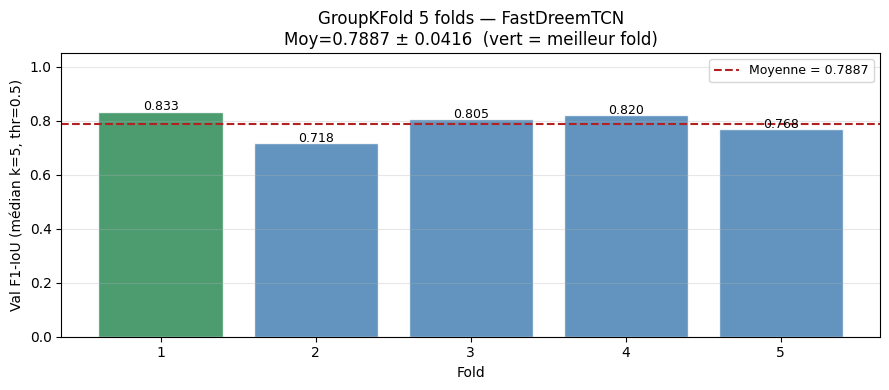

Figure : /kaggle/working/figures/fold_f1_fast_tcn.png


In [26]:
# ── Figure résumé des folds ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['seagreen' if r['fold']==best_fold_num else 'steelblue' for r in fold_results]
bars   = ax.bar(range(1, N_FOLDS+1), f1_vals, color=colors, edgecolor='white', alpha=0.85)
ax.axhline(np.mean(f1_vals), color='firebrick', linestyle='--',
           label=f'Moyenne = {np.mean(f1_vals):.4f}')
for i,v in enumerate(f1_vals):
    ax.text(i+1, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xlabel('Fold'); ax.set_ylabel('Val F1-IoU (médian k=5, thr=0.5)')
ax.set_title(f'GroupKFold 5 folds — FastDreemTCN\n'
             f'Moy={np.mean(f1_vals):.4f} ± {np.std(f1_vals):.4f}  '
             f'(vert = meilleur fold)')
ax.legend(fontsize=9); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fp = FIGURES_DIR / 'fold_f1_fast_tcn.png'
plt.savefig(fp, dpi=100, bbox_inches='tight'); plt.show()
print(f"Figure : {fp}")

---

## 8. Calibration du threshold sur prédictions OOF

Les prédictions OOF (3400 fenêtres, chaque sujet passé 1 fois en val) sont
l'estimateur le plus fiable du score public. Le threshold calibré ici sera
utilisé directement pour l'inférence test final.

Calibration threshold sur prédictions OOF ...

 Threshold | F1-IoU OOF
-------------------------
      0.10 |     0.5729
      0.15 |     0.6297
      0.20 |     0.6751
      0.25 |     0.7008
      0.30 |     0.7269
      0.35 |     0.7474
      0.40 |     0.7649
      0.45 |     0.7780
      0.50 |     0.7871
      0.55 |     0.7978
      0.60 |     0.8033
      0.65 |     0.8106
      0.70 |     0.8182
      0.75 |     0.8259
      0.80 |     0.8303
      0.85 |     0.8309 ← optimal
      0.90 |     0.8237

Threshold optimal OOF : 0.85
F1-IoU OOF calibré    : 0.8309
% apnées OOF (thr=0.85) : 4.53%  (ref train : 7.56%)


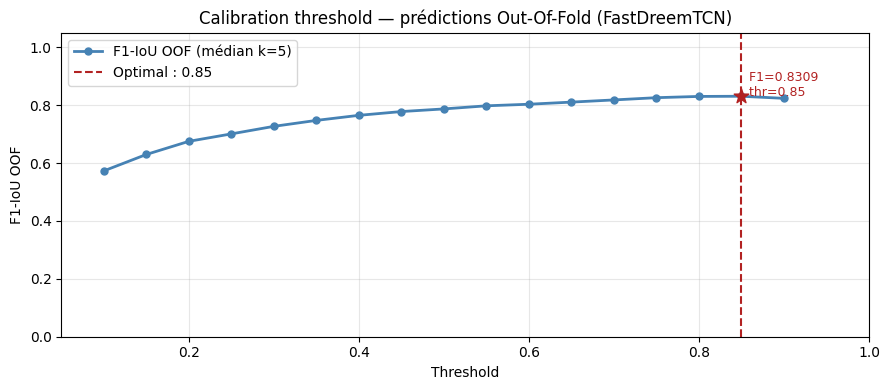

Figure : /kaggle/working/figures/oof_threshold_fast_tcn.png


In [27]:
# ── Calibration OOF ──────────────────────────────────────────────────────────
print("Calibration threshold sur prédictions OOF ...")

best_thr, best_f1_oof, f1s, thrs = calibrate_threshold(
    y_train, oof_probs, kernel_size=KERN_MED)

print(f"\n{'Threshold':>10} | {'F1-IoU OOF':>10}")
print("-" * 25)
for t, f in zip(thrs, f1s):
    m = " ← optimal" if abs(t-best_thr)<1e-9 else ""
    print(f"{t:>10.2f} | {f:>10.4f}{m}")

print(f"\nThreshold optimal OOF : {best_thr:.2f}")
print(f"F1-IoU OOF calibré    : {best_f1_oof:.4f}")

# ── Sanity : distribution apnées avec ce threshold ───────────────────────────
oof_smooth = apply_median_filter(oof_probs, KERN_MED)
oof_preds  = (oof_smooth >= best_thr).astype(int)
print(f"% apnées OOF (thr={best_thr:.2f}) : {oof_preds.mean()*100:.2f}%  "
      f"(ref train : {y_train.mean()*100:.2f}%)")

# ── Courbe F1 vs threshold ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thrs, f1s, color='steelblue', lw=2, marker='o', ms=5,
        label='F1-IoU OOF (médian k=5)')
ax.axvline(best_thr, color='firebrick', linestyle='--', lw=1.5,
           label=f'Optimal : {best_thr:.2f}')
ax.scatter([best_thr], [best_f1_oof], color='firebrick', zorder=5, s=120, marker='*')
ax.annotate(f'  F1={best_f1_oof:.4f}\n  thr={best_thr:.2f}',
            xy=(best_thr, best_f1_oof), fontsize=9, color='firebrick')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-IoU OOF')
ax.set_title('Calibration threshold — prédictions Out-Of-Fold (FastDreemTCN)')
ax.set_xlim(0.05, 1.); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fp = FIGURES_DIR / 'oof_threshold_fast_tcn.png'
plt.savefig(fp, dpi=100, bbox_inches='tight'); plt.show()
print(f"Figure : {fp}")

---

## 9. Entraînement final & inférence test

### Stratégie

Entraînement sur les **3400 samples** (tous les 17 sujets) pendant un nombre
d'epochs fixe, estimé comme la moyenne des meilleurs epochs par fold.
Pas d'early stopping (pas de val séparée au stade final).

Epochs par fold : [13, 16, 5, 15, 6]
Epochs final    : 14

Entraînement final — 14 epochs / 3400 samples
Epoch 01/14 | Loss: 0.6994 | LR: 9.88e-04
Epoch 02/14 | Loss: 0.5563 | LR: 9.51e-04
Epoch 03/14 | Loss: 0.5275 | LR: 8.92e-04
Epoch 04/14 | Loss: 0.4837 | LR: 8.14e-04
Epoch 05/14 | Loss: 0.4576 | LR: 7.20e-04
Epoch 06/14 | Loss: 0.4457 | LR: 6.15e-04
Epoch 07/14 | Loss: 0.4054 | LR: 5.05e-04
Epoch 08/14 | Loss: 0.3892 | LR: 3.95e-04
Epoch 09/14 | Loss: 0.3664 | LR: 2.90e-04
Epoch 10/14 | Loss: 0.3261 | LR: 1.96e-04
Epoch 11/14 | Loss: 0.3173 | LR: 1.18e-04
Epoch 12/14 | Loss: 0.2842 | LR: 5.90e-05
Epoch 13/14 | Loss: 0.2661 | LR: 2.24e-05
Epoch 14/14 | Loss: 0.2643 | LR: 1.00e-05

Modèle sauvegardé : /kaggle/working/best_model_tcn_final.pth


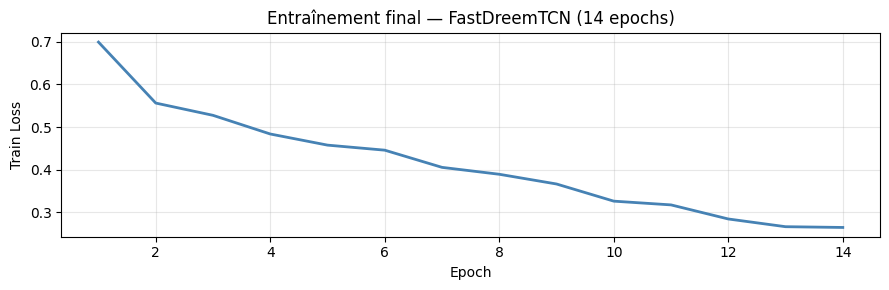

Figure : /kaggle/working/figures/final_loss_fast_tcn.png


In [28]:
# ── Nombre d'epochs final ────────────────────────────────────────────────────
N_EP_FINAL = min(int(np.mean([r['best_epoch'] for r in fold_results])) + 3,
                 MAX_EPOCHS)
print(f"Epochs par fold : {[r['best_epoch'] for r in fold_results]}")
print(f"Epochs final    : {N_EP_FINAL}")

# ── Dataset & DataLoader ──────────────────────────────────────────────────────
nw = 2 if device.type != 'mps' else 0
dl_all = DataLoader(
    DreemDatasetFast(X_train, y_train, augment=True),
    batch_size=BS_TRAIN, shuffle=True, num_workers=nw,
    pin_memory=(device.type=='cuda'))

# ── Modèle final ──────────────────────────────────────────────────────────────
FINAL_PATH = OUTPUT_DIR / 'best_model_tcn_final.pth'
model_f = FastDreemTCN(n_channels=N_SIGNALS).to(device)
crit_f  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT]).to(device))
optim_f = torch.optim.Adam(model_f.parameters(), lr=LR, weight_decay=WD)
sched_f = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_f, T_max=N_EP_FINAL, eta_min=1e-5)

print(f"\nEntraînement final — {N_EP_FINAL} epochs / {len(X_train)} samples")
print("=" * 50)
losses = []
for epoch in range(1, N_EP_FINAL + 1):
    model_f.train(); ep_loss = 0.
    for xb, yb in dl_all:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optim_f.zero_grad(set_to_none=True)
        loss = crit_f(model_f(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_f.parameters(), 1.0)
        optim_f.step()
        ep_loss += loss.item()
    ep_loss /= len(dl_all)
    sched_f.step()
    losses.append(ep_loss)
    print(f"Epoch {epoch:02d}/{N_EP_FINAL} | Loss: {ep_loss:.4f} | "
          f"LR: {optim_f.param_groups[0]['lr']:.2e}")

torch.save({'model_state': model_f.state_dict(),
            'best_thr': best_thr, 'kern_med': KERN_MED,
            'oof_f1': best_f1_oof}, FINAL_PATH)
print(f"\nModèle sauvegardé : {FINAL_PATH}")

# Courbe de loss
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(1, N_EP_FINAL+1), losses, color='steelblue', lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss')
ax.set_title(f'Entraînement final — FastDreemTCN ({N_EP_FINAL} epochs)')
ax.grid(alpha=0.3); plt.tight_layout()
fp = FIGURES_DIR / 'final_loss_fast_tcn.png'
plt.savefig(fp, dpi=100, bbox_inches='tight'); plt.show()
print(f"Figure : {fp}")

Inférence sur X_test (4400 fenêtres) ...
  Filtre médian k=5  |  Threshold=0.85


Test inference:   0%|          | 0/69 [00:00<?, ?it/s]


% apnées test  : 8.41%
% apnées train : 7.56%
Ratio          : 1.11
Distribution cohérente ✓

submission_v6.csv sauvegardé : /kaggle/working/submission_v6.csv
Shape : (4400, 91)
     id  y_0  y_1  y_2  y_3  y_4  y_5  y_6
0  4400    1    1    1    0    0    0    0
1  4401    0    0    0    0    0    0    0
2  4402    0    0    0    0    0    0    0
...


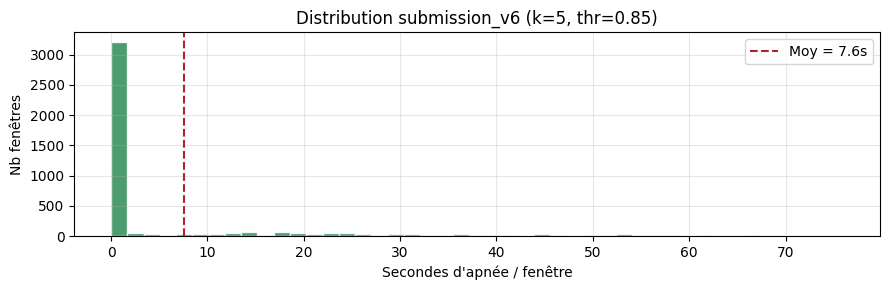

Figure : /kaggle/working/figures/submission_v6_distribution.png


In [29]:
# ── Inférence test ────────────────────────────────────────────────────────────
print(f"Inférence sur X_test ({len(X_test)} fenêtres) ...")
print(f"  Filtre médian k={KERN_MED}  |  Threshold={best_thr:.2f}")

dl_te = DataLoader(
    DreemDatasetFast(X_test, y=None, augment=False),
    batch_size=BS_VAL, shuffle=False, num_workers=nw,
    pin_memory=(device.type=='cuda'))

model_f.eval(); raw_probs = []
with torch.no_grad():
    for xb in tqdm(dl_te, desc='Test inference'):
        p = torch.sigmoid(model_f(xb.to(device))).cpu().numpy()
        raw_probs.append(p)

raw_probs    = np.concatenate(raw_probs,  axis=0)           # (4400, 90)
smooth_probs = apply_median_filter(raw_probs, KERN_MED)     # (4400, 90)
preds_test   = (smooth_probs >= best_thr).astype(np.int8)   # (4400, 90)

# ── Sanity check ─────────────────────────────────────────────────────────────
pct_test  = preds_test.mean()  * 100
pct_train = y_train.mean()     * 100
ratio     = pct_test / pct_train
print(f"\n% apnées test  : {pct_test:.2f}%")
print(f"% apnées train : {pct_train:.2f}%")
print(f"Ratio          : {ratio:.2f}")
if 0.5 <= ratio <= 2.0:
    print("Distribution cohérente ✓")
else:
    print(f"⚠ Ratio anormal ({ratio:.2f}) — "
          + ("trop peu de prédictions positives, baisser le threshold"
             if ratio < 0.5 else "trop de positives, monter le threshold"))

# ── Soumission ────────────────────────────────────────────────────────────────
label_cols  = [f'y_{i}' for i in range(N_LABEL_COLS)]
df_sub      = pd.DataFrame(preds_test, columns=label_cols)
df_sub.insert(0, 'id', test_ids)
sub_path    = SUBMIT_DIR / 'submission_v6.csv'
df_sub.to_csv(sub_path, index=False)
print(f"\nsubmission_v6.csv sauvegardé : {sub_path}")
print(f"Shape : {df_sub.shape}")
print(df_sub.iloc[:3, :8].to_string()); print("...")

# ── Distribution ─────────────────────────────────────────────────────────────
apnea_per_win = preds_test.sum(axis=1)
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(apnea_per_win, bins=45, color='seagreen', edgecolor='white', alpha=0.85)
ax.axvline(apnea_per_win.mean(), color='firebrick', linestyle='--',
           label=f'Moy = {apnea_per_win.mean():.1f}s')
ax.set_xlabel("Secondes d'apnée / fenêtre")
ax.set_ylabel('Nb fenêtres')
ax.set_title(f'Distribution submission_v6 (k={KERN_MED}, thr={best_thr:.2f})')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
fp = FIGURES_DIR / 'submission_v6_distribution.png'
plt.savefig(fp, dpi=100, bbox_inches='tight'); plt.show()
print(f"Figure : {fp}")

---

## 10. Conclusion & comparaison

| Aspect | CNN+BiLSTM (v1) | **FastDreemTCN (v6)** |
|---|---|---|
| **Normalisation** | Globale (scaler train) | Par fenêtre (instance norm) |
| **Validation** | Split biaisé (5 sujets légers) | GroupKFold 5 folds |
| **Architecture** | CNN + BiLSTM récurrent | CNN réduction + TCN dilaté |
| **TCN opère sur** | — | 90 pts (1 pt/s) — rapide |
| **Champ récepteur TCN** | — | 61 s — couvre toute la fenêtre |
| **Paramètres** | ~261 K | ~290 K |
| **Temps / fold** | ~8 min | ~6 min (T4) |
| **Val F1 rapporté** | 0.80 (biaisé) | OOF F1 (honnête) |
| **Score public** | 0.447 | ? |

### Pourquoi le gap val/public devrait être réduit

1. **Instance normalization** → sujets test normalisés par leurs propres stats,
   plus de décalage distribution.
2. **OOF calibration** → threshold estimé sur sujets jamais vus à l'entraînement,
   cohérent avec les conditions du test set.
3. **Architecture TCN** → pas de LSTM récurrent, moins de paramètres de mémoire
   à surapprendre sur 17 sujets.

### Prochaines pistes si score insuffisant

- Ajouter les 5 sujets val originaux au GroupKFold (charger `X_train.h5`)
- Post-processing morphologique : supprimer les événements < 5 s
- Augmenter dilatations TCN jusqu'à `d=16` pour RF = 125 s
- Pseudo-labelling sur prédictions test très confiantes (p > 0.95)

---
*Notebook 06 — Challenge ENS #45 — Dreem Sleep Apnea Detection*